### Before you execute the notebook please run: 
#### 01_sync_data.py to download the audio files from azure
#### 02_extract_features.py to splitting the files and for feature extraction and augmentation

# Importing

In [5]:
import sys
sys.path.append('src')
import io
import os
import pickle
import time
import warnings
import librosa
import numpy as np
import pandas as pd
import tensorflow as tf
!pip install azure-storage-blob
!pip install seaborn python-dotenv librosa scikit-learn
from azure.storage.blob import BlobServiceClient
from dotenv import load_dotenv
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
)
import tensorflow.keras.layers as L
from src.audio_pipeline import extract_features_from_audio_array, get_feature_names
from src.config import (
    ASSETS_DIR,
    ENCODER_PATH,
    MODEL_PATH,
    MONO,
    N_FEATURES, 
    SCALER_PATH,
    TARGET_SR,
)
from src.manifest_builder import (
    add_augmented_rows,
    assign_splits,
    build_manifest,
    save_manifest,
    validate_manifest,
)
from src.speaker_splitter import add_speaker_column, speaker_split

warnings.filterwarnings("ignore")
load_dotenv()


True

# Integration with Azure

In [6]:
import sys
sys.path.append('src')
from azure.storage.blob import BlobServiceClient
import pandas as pd
import os
from dotenv import load_dotenv
import numpy as np
import io
import librosa


load_dotenv()

CONTAINER_NAME = "wav-files"

connection_string = os.getenv("AZURE_STORAGE_CONNECTION_STRING")

if not connection_string:
    raise ValueError("AZURE_STORAGE_CONNECTION_STRING not set")

blob_service = BlobServiceClient.from_connection_string(connection_string)
container_client = blob_service.get_container_client(CONTAINER_NAME)


def get_df_from_blob_dataset(prefix):
    emotions = []
    file_paths = []

    for blob in container_client.list_blobs(name_starts_with=prefix):
        if blob.name.endswith(".wav"):
            filename = blob.name.split("/")[-1]
            parts = filename.split("-")

            if len(parts) >= 3:
                emotion = parts[2].lower()
            else:
                emotion = "unknown"

            emotions.append(emotion)
            file_paths.append(blob.name)

    return pd.DataFrame({
        "Path": file_paths,
        "Emotions": emotions
    })


def load_audio_from_blob(blob_service, blob_path: str) -> tuple[np.ndarray, int]:
    clean_path = blob_path.replace("\\", "/")
    blob_client = blob_service.get_blob_client(container=CONTAINER_NAME, blob=clean_path)
    audio_file = io.BytesIO(blob_client.download_blob().readall())
    data, sr = librosa.load(audio_file, sr=TARGET_SR, mono=MONO)
    return data.astype(np.float32), sr


ravdess_df = get_df_from_blob_dataset("RAVDESS/")
crema_df   = get_df_from_blob_dataset("CREMAD/")
tess_df    = get_df_from_blob_dataset("TESS/")
savee_df   = get_df_from_blob_dataset("SAVEE/")
asvp_df    = get_df_from_blob_dataset("ASVP-ESD/")  

data_path = pd.concat(
    [ravdess_df, crema_df, tess_df, savee_df, asvp_df],  
    axis=0
).reset_index(drop=True)

os.makedirs("data/csv", exist_ok=True)
data_path.to_csv("data/csv/data_path.csv", index=False)

print("Total files:", len(data_path))
print(data_path.head())
print("\nEmotion distribution:")
print(data_path["Emotions"].value_counts())


Total files: 8515
                                           Path Emotions
0  RAVDESS/Actor_01/RAVDESS-01-Angry-1-dup0.wav    angry
1  RAVDESS/Actor_01/RAVDESS-01-Angry-1-dup1.wav    angry
2  RAVDESS/Actor_01/RAVDESS-01-Angry-1-dup2.wav    angry
3  RAVDESS/Actor_01/RAVDESS-01-Angry-1-dup3.wav    angry
4  RAVDESS/Actor_01/RAVDESS-01-Angry-2-dup0.wav    angry

Emotion distribution:
Emotions
angry      2190
neutral    2180
happy      2118
sad        2027
Name: count, dtype: int64


# EDA

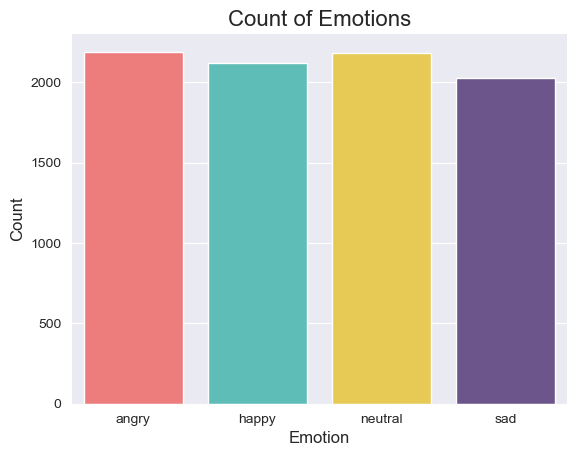

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.countplot(
    x=data_path["Emotions"],
    palette=["#FF6B6B", "#4ECDC4", "#FFD93D", "#6A4C93"]
)

plt.title('Count of Emotions', size=16)
plt.xlabel('Emotion', size=12)
plt.ylabel('Count', size=12)

sns.despine()
plt.show()

# Data Augmentation Functions

In [4]:

def noise(data, sr=None):
    noise_amp = 0.035 * np.random.uniform() * np.max(np.abs(data))
    return data + noise_amp * np.random.normal(size=data.shape[0])


def stretch(data, sr=None, rate=0.8):
    return librosa.effects.time_stretch(y=data, rate=rate)


def shift(data, sr=None):
    shift_range = int(np.random.uniform(-5, 5) * 1000)
    return np.roll(data, shift_range)


def pitch(data, sr, n_steps=0.7):
    return librosa.effects.pitch_shift(y=data, sr=sr, n_steps=n_steps)


AUGMENTATIONS = {
    "noise":   lambda d, sr: noise(d, sr),
    "stretch": lambda d, sr: stretch(d, sr),
    "shift":   lambda d, sr: shift(d, sr),
    "pitch":   lambda d, sr: pitch(d, sr),
}

# Data Preparation (Scaling & Encoding)

In [5]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

train_df2 = pd.read_csv("data/csv/train_features_ready_for_model.csv")
val_df2   = pd.read_csv("data/csv/val_features_ready_for_model.csv")
test_df2  = pd.read_csv("data/csv/test_features_ready_for_model.csv")

# Load (128, 128) spectrograms from .npy files
X_train = np.stack([np.load(p) for p in train_df2["npy_path"]])  # (N, 128, 128)
X_val   = np.stack([np.load(p) for p in val_df2["npy_path"]])
X_test  = np.stack([np.load(p) for p in test_df2["npy_path"]])

# Add channel dim for 2D CNN: (N, 128, 128, 1)
x_traincnn = X_train[..., np.newaxis]
x_valcnn   = X_val[..., np.newaxis]
x_testcnn  = X_test[..., np.newaxis]

# Encode labels
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
y_train = encoder.fit_transform(train_df2["Labels"].values.reshape(-1, 1))
y_val   = encoder.transform(val_df2["Labels"].values.reshape(-1, 1))
y_test  = encoder.transform(test_df2["Labels"].values.reshape(-1, 1))

print(f"Train: {x_traincnn.shape}  Val: {x_valcnn.shape}  Test: {x_testcnn.shape}")
print(f"Classes: {encoder.categories_[0]}")


Train: (29729, 128, 128, 1)  Val: (1275, 128, 128, 1)  Test: (1276, 128, 128, 1)
Classes: ['angry' 'happy' 'neutral' 'sad']


# CNN Arcticeture

In [ ]:
import sys
sys.path.insert(0, 'src')
import tensorflow as tf
from tensorflow.keras import layers as L, regularizers
from src.config import (
    N_MELS, FIXED_FRAMES,
    L2_REG, CNN_DROPOUT_CONV, CNN_DROPOUT_DENSE, CNN_DENSE_UNITS,
)

l2_reg = regularizers.l2(L2_REG)

model = tf.keras.Sequential([
    L.Conv2D(32, (3, 3), padding="same", activation="relu",
             kernel_regularizer=l2_reg,
             input_shape=(N_MELS, FIXED_FRAMES, 1)),   # ← was (128, 128, 1)
    L.BatchNormalization(),
    L.MaxPooling2D((2, 2)),

    L.Conv2D(64, (3, 3), padding="same", activation="relu", kernel_regularizer=l2_reg),
    L.BatchNormalization(),
    L.MaxPooling2D((2, 2)),
    L.Dropout(CNN_DROPOUT_CONV),                        # ← was 0.4

    L.Conv2D(128, (3, 3), padding="same", activation="relu", kernel_regularizer=l2_reg),
    L.BatchNormalization(),
    L.MaxPooling2D((2, 2)),
    L.Dropout(CNN_DROPOUT_CONV),                        # ← was 0.4

    L.Conv2D(128, (3, 3), padding="same", activation="relu", kernel_regularizer=l2_reg),
    L.BatchNormalization(),
    L.GlobalAveragePooling2D(),

    L.Dense(CNN_DENSE_UNITS, activation="relu"),        # ← was 64
    L.Dropout(CNN_DROPOUT_DENSE),                       # ← was 0.5
    L.Dense(y_train.shape[1], activation="softmax"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),  # ← was 0.0005
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,180 (977.27 KB)

 Trainable params: 249,476 (974.52 KB)

 Non-trainable params: 704 (2.75 KB)

# Training Callbacks

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import sys
sys.path.insert(0, 'src')
from src.config import ( MODEL_PATH, EARLY_STOPPING_PATIENCE, LR_REDUCE_PATIENCE, LR_REDUCE_FACTOR, LR_MIN,)

callbacks = [
    ModelCheckpoint(str(MODEL_PATH), monitor="val_accuracy", save_best_only=True, verbose=1),

    EarlyStopping(monitor="val_accuracy", mode="max", patience=EARLY_STOPPING_PATIENCE, restore_best_weights=True, verbose=1),

    ReduceLROnPlateau(monitor="val_accuracy", patience=LR_REDUCE_PATIENCE, factor=LR_REDUCE_FACTOR, min_lr=LR_MIN, verbose=1),
]


# CNN Model

Epoch 1/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5002 - loss: 1.3252
Epoch 1: val_accuracy improved from None to 0.22588, saving model to C:\Users\orbit_24ts2or\OneDrive\שולחן העבודה\Emotion-Recognition\model_assets\final_emotion_model.keras

Epoch 1: finished saving model to C:\Users\orbit_24ts2or\OneDrive\שולחן העבודה\Emotion-Recognition\model_assets\final_emotion_model.keras
465/465 ━━━━━━━━━━━━━━━━━━━━ 661s 1s/step - accuracy: 0.5723 - loss: 1.1813 - val_accuracy: 0.2259 - val_loss: 2.7055 - learning_rate: 5.0000e-04
Epoch 2/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6601 - loss: 0.9635
Epoch 2: val_accuracy improved from 0.22588 to 0.24392, saving model to C:\Users\orbit_24ts2or\OneDrive\שולחן העבודה\Emotion-Recognition\model_assets\final_emotion_model.keras

Epoch 2: finished saving model to C:\Users\orbit_24ts2or\OneDrive\שולחן העבודה\Emotion-Recognition\model_assets\final_emotion_model.keras
465/465 ━━━━━━━━━━━━━━━━━━━━ 486s 1s/step - accuracy: 0.6

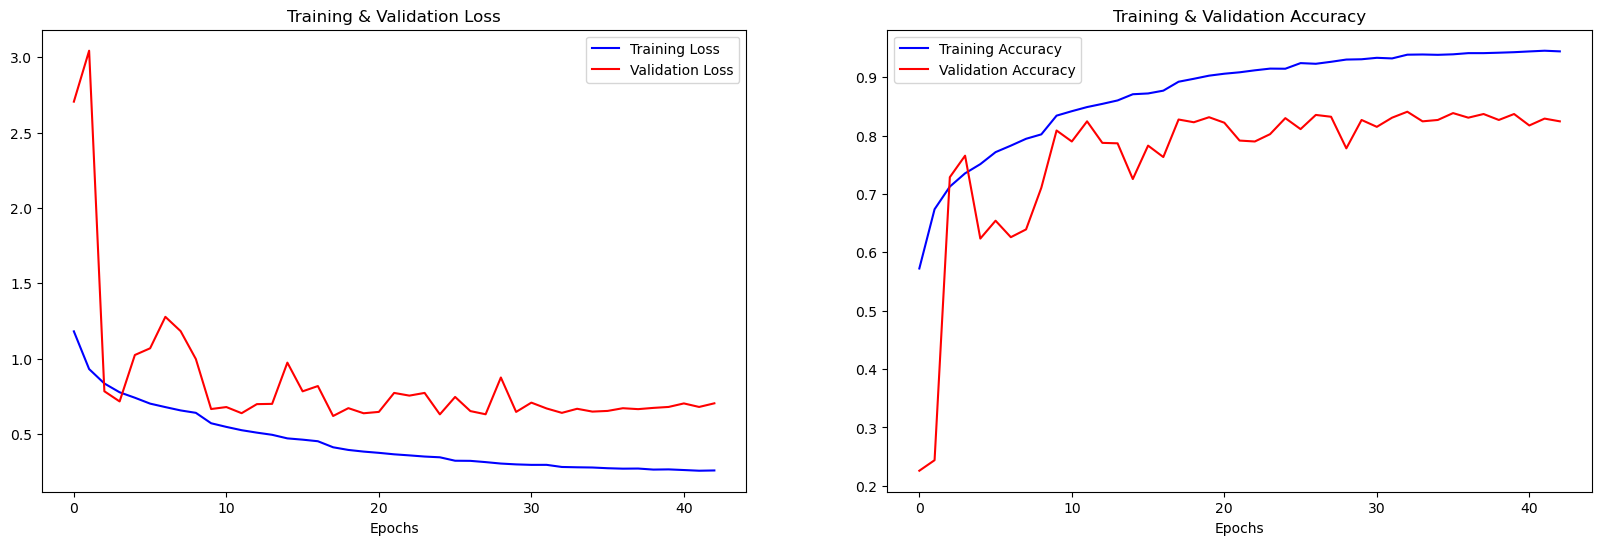

In [ ]:
import matplotlib.pyplot as plt
from src.config import EPOCHS


# --- The actual training step ---
history = model.fit(
    x_traincnn, y_train,
    epochs=EPOCHS,                                          
    validation_data=(x_valcnn, y_val),
    callbacks=callbacks,
)


print(" Model has finished training.")


print("Plotting training history...")
epochs = range(len(history.history['accuracy']))
fig, ax = plt.subplots(1, 2, figsize=(20, 6))

# Plotting Loss
ax[0].plot(epochs, history.history['loss'], label='Training Loss', color='blue')
ax[0].plot(epochs, history.history['val_loss'], label='Validation Loss', color='red')
ax[0].set_title('Training & Validation Loss')
ax[0].legend()
ax[0].set_xlabel("Epochs")

# Plotting Accuracy
ax[1].plot(epochs, history.history['accuracy'], label='Training Accuracy', color='blue')
ax[1].plot(epochs, history.history['val_accuracy'], label='Validation Accuracy', color='red')
ax[1].set_title('Training & Validation Accuracy')
ax[1].legend()
ax[1].set_xlabel("Epochs")

plt.show()

In [19]:
# predicting on test data.
pred_test0 = model.predict(x_testcnn)
y_pred0 = encoder.inverse_transform(pred_test0)
y_test0 = encoder.inverse_transform(y_test)

# Check for random predictions
df0 = pd.DataFrame(columns=['Predicted Labels', 'Actual Labels'])
df0['Predicted Labels'] = y_pred0.flatten()
df0['Actual Labels'] = y_test0.flatten()

df0.head(10)


40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step


,Predicted Labels,Actual Labels
0,angry,angry
1,angry,angry
2,angry,angry
3,angry,angry
4,angry,angry
5,angry,angry
6,angry,angry
7,angry,angry
8,angry,angry
9,angry,angry


# Evaluation

In [21]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt


pred_test = model.predict(x_testcnn)

y_pred_labels = encoder.inverse_transform(pred_test)
y_test_labels = encoder.inverse_transform(y_test)

cm = confusion_matrix(y_test_labels, y_pred_labels)

labels = encoder.categories_[0]

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix - Audio Emotion Recognition', size=20)
plt.xlabel('Predicted Labels (What the model thought)', size=14)
plt.ylabel('Actual Labels (The Truth)', size=14)
plt.show()

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test_labels, y_pred_labels))

NameError: name 'model' is not defined

# Saving the model

In [21]:
import sys
sys.path.append('src')
import os
import pickle

# Create assets folder 
ASSETS_DIR = 'model_assets'
os.makedirs(ASSETS_DIR, exist_ok=True)

# Create Voxonics_audio directory for placing audio files to analyze
os.makedirs('Voxonics_audio', exist_ok=True)
print("Created 'Voxonics_audio/' — place your .wav files here to analyze.")

# Save model 
model_path = os.path.join(ASSETS_DIR, 'final_emotion_model.keras')
model.save(model_path)
print(f"Model saved to: {model_path}")

# Save encoder
with open(os.path.join(ASSETS_DIR, 'encoder.pickle'), 'wb') as f:
    pickle.dump(encoder, f)

print(f"Assets saved to: {ASSETS_DIR}/")

# ===== Generate Voxonics_Predictions.py in the project root =====
script_content = '''"""
Voxonics Emotion Predictions
==============================
Predicts the emotion of a speaker from a .wav audio file.

HOW TO RUN:
-----------
Single file:
    .venv\\Scripts\\python.exe Voxonics_Predictions.py Voxonics_audio\\your_file.wav

All files in Voxonics_audio folder (PowerShell):
    Get-ChildItem .\\Voxonics_audio\\*.wav | ForEach-Object {
        .venv\\Scripts\\python.exe Voxonics_Predictions.py $_.FullName
    }
"""

import os
import sys
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath(__file__)), "src"))

import pickle
import warnings
import numpy as np
from tensorflow.keras.models import load_model

from audio_pipeline import extract_spectrogram_from_file
from config import MODEL_PATH, ENCODER_PATH

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"


def load_engine():
    print("--- Loading Voxonics Engine ---")
    model = load_model(MODEL_PATH)

    with open(ENCODER_PATH, "rb") as f:
        encoder = pickle.load(f)

    return model, encoder


def predict_emotions_report(audio_path):
    model, encoder = load_engine()

    spec = extract_spectrogram_from_file(audio_path)
    features_cnn = spec[np.newaxis, ..., np.newaxis]  # (1, 128, 128, 1)

    predictions = model.predict(features_cnn, verbose=0)[0]
    emotion_labels = encoder.categories_[0]

    return {label: float(prob * 100) for label, prob in zip(emotion_labels, predictions)}


if __name__ == "__main__":
    test_audio = sys.argv[1] if len(sys.argv) > 1 else "test_voice.wav"

    if os.path.exists(test_audio):
        print(f"Analyzing: {test_audio}")
        results = predict_emotions_report(test_audio)

        print("=" * 40)
        for emotion, confidence in sorted(results.items(), key=lambda x: x[1], reverse=True):
            bar = "█" * int(confidence / 5)
            print(f"{emotion.ljust(12)} | {confidence:6.2f}% {bar}")
        print("=" * 40)
    else:
        print(f"File not found: {test_audio}")
'''

with open("Voxonics_Predictions.py", "w", encoding="utf-8") as f:
    f.write(script_content)

print("Voxonics_Predictions.py created!")


Created 'Voxonics_audio/' — place your .wav files here to analyze.
Model saved to: model_assets\final_emotion_model.keras
Assets saved to: model_assets/
Voxonics_Predictions.py created!


# Unit Test

### Every time ther's a change in function in audio_pipeline.py, augmentation.py, or speaker_splitter.py
### Run the tests again to make sure nothing is broken

In [15]:
import unittest
import sys
from pathlib import Path

project_root = Path.cwd()

sys.path.insert(0, str(project_root / "src"))
sys.path.insert(0, str(project_root / "tests"))

loader = unittest.TestLoader()
suite = unittest.TestSuite()

for test_module in [
    "test_audio_pipeline",
    "test_speaker_splitter",
    "test_augmentation",
]:
    suite.addTests(loader.loadTestsFromName(test_module))

runner = unittest.TextTestRunner(verbosity=2, stream=sys.stdout)
result = runner.run(suite)

test_crops_long_audio (test_audio_pipeline.TestCropOrPad.test_crops_long_audio) ... ok
test_exact_length_unchanged (test_audio_pipeline.TestCropOrPad.test_exact_length_unchanged) ... ok
test_invalid_crop_mode_raises (test_audio_pipeline.TestCropOrPad.test_invalid_crop_mode_raises) ... ok
test_invalid_pad_mode_raises (test_audio_pipeline.TestCropOrPad.test_invalid_pad_mode_raises) ... ok
test_output_is_float32 (test_audio_pipeline.TestCropOrPad.test_output_is_float32) ... ok
test_pads_short_audio (test_audio_pipeline.TestCropOrPad.test_pads_short_audio) ... ok
test_feature_vector_is_float32 (test_audio_pipeline.TestExtractFeatures.test_feature_vector_is_float32) ... ok
test_feature_vector_length (test_audio_pipeline.TestExtractFeatures.test_feature_vector_length) ... ok
test_feature_vector_no_inf (test_audio_pipeline.TestExtractFeatures.test_feature_vector_no_inf) ... ok
test_feature_vector_no_nan (test_audio_pipeline.TestExtractFeatures.test_feature_vector_no_nan) ... ok
test_load_from